# MHC-I Predictor Concordance: MHCflurry vs HLApollo on HCC1395

**Purpose:** Compare the two presentation predictors on the full HCC1395 pipeline output to understand where they agree and disagree.

**Data requirements:**
- HCC1395 annotated VCF: `data/HCC1395_inputs/annotated.expression.vcf.gz`
- HLA types: `data/HCC1395_inputs/optitype_normal_result.tsv` (OptiType format)
- Reference proteome: `data/HCC1395_inputs/Homo_sapiens.GRCh38.pep.all.fa.gz`
- HLApollo binary: `tools/HLApollo/HLA-Apollo` (or Docker image)

Run cells top-to-bottom. Both predictors are run on the same peptide candidates derived from HCC1395 somatic variants.

## 1. Setup and data loading

In [5]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

from neoantigen_pipeline.candidates.peptide_generator import PeptideGenerator
from neoantigen_pipeline.config import MHCIPredictionConfig, PeptideGenerationConfig
from neoantigen_pipeline.io.hla_reader import HLAReader
from neoantigen_pipeline.io.proteome import ProteomeDB
from neoantigen_pipeline.io.vcf_reader import VCFReader
from neoantigen_pipeline.prediction.hlapollo import HLApolloPredictor
from neoantigen_pipeline.prediction.mhcflurry import MHCflurryPredictor

sns.set_theme(style="whitegrid", font_scale=1.2)
plt.rcParams["figure.figsize"] = (10, 6)
%matplotlib inline

# Paths
DATA_DIR = Path("../data/HCC1395_inputs")
VCF_PATH = DATA_DIR / "annotated.expression.vcf.gz"
HLA_PATH = DATA_DIR / "optitype_normal_result.tsv"
PROTEOME_PATH = DATA_DIR / "Homo_sapiens.GRCh38.pep.all.fa.gz"
# HLAPOLLO_BINARY kept for reference; Docker is used by default
HLAPOLLO_BINARY = Path("../tools/HLApollo/HLA-Apollo")

TEST_RUN = True
print("Imports OK")

Imports OK


In [6]:
# Load HLA types
hla_reader = HLAReader()
hla = hla_reader.read_optitype(str(HLA_PATH))
alleles = list(hla.class_i_alleles)
print(f"HLA-I alleles: {alleles}")

# Load variants (all somatic variant types)
vcf_reader = VCFReader(str(VCF_PATH))
variants = vcf_reader.read_variants()
print(f"Loaded {len(variants)} variants")

# Load proteome
print("Loading proteome (may take a moment)...")
proteome = ProteomeDB(str(PROTEOME_PATH))
print("Proteome loaded.")

# Generate peptide candidates
pg_config = PeptideGenerationConfig(peptide_lengths=(8, 9, 10, 11), n_flank_length=10, c_flank_length=10)
generator = PeptideGenerator(pg_config, proteome)
all_candidates = []
for variant in variants:
    all_candidates.extend(generator.generate(variant))

if TEST_RUN:
    all_candidates = all_candidates[:100]
print(f"Generated {len(all_candidates)} peptide candidates")

HLA-I alleles: ['HLA-A*29:02', 'HLA-B*45:01', 'HLA-B*82:02', 'HLA-C*06:02']
Loaded 1209 variants
Loading proteome (may take a moment)...


OR4F29_p.Glu11Ter: filtered 38 peptide candidate(s) containing non-standard amino acids (kept 0)
IGSF3_p.Glu1036_Glu1037insTer: filtered 34 peptide candidate(s) containing non-standard amino acids (kept 0)
IGSF3_p.Glu1036_Glu1037insTer: filtered 34 peptide candidate(s) containing non-standard amino acids (kept 0)
IGSF3_p.Glu1016_Glu1017insTer: filtered 34 peptide candidate(s) containing non-standard amino acids (kept 0)
ST6GAL2_p.Ser2Cys: filtered 4 peptide candidate(s) containing non-standard amino acids (kept 4)
TXNDC15_p.Ser7Pro: filtered 4 peptide candidate(s) containing non-standard amino acids (kept 24)


Proteome loaded.


Reference mismatch at ENST00000263549.8 pos 662: expected 'VF', found 'VI' in proteome
FGFR1_p.Ser6Leu: filtered 4 peptide candidate(s) containing non-standard amino acids (kept 20)
Reference mismatch at ENST00000263088.11 pos 663: expected 'DK', found 'DR' in proteome
Reference mismatch at ENST00000572940.5 pos 663: expected 'DK', found 'DR' in proteome
Reference mismatch at ENST00000576983.5 pos 61: expected 'DK', found 'DR' in proteome
Reference mismatch at ENST00000310706.9 pos 40: expected 'KY', found 'KG' in proteome
Reference mismatch at ENST00000393930.5 pos 40: expected 'KY', found 'KG' in proteome
Reference mismatch at ENST00000393931.8 pos 40: expected 'KY', found 'KG' in proteome
Reference mismatch at ENST00000420370.5 pos 40: expected 'KY', found 'KG' in proteome
Reference mismatch at ENST00000424457.5 pos 40: expected 'KY', found 'KG' in proteome
Reference mismatch at ENST00000437187.5 pos 40: expected 'KY', found 'KG' in proteome
Reference mismatch at ENST00000437369.5 p

Generated 100 peptide candidates


In [7]:
from neoantigen_pipeline.results.cache import PredictionCache

cache = PredictionCache("../results/cache")

# MHCflurry
mf_key = cache.make_key("mhcflurry", len(all_candidates), alleles)
mf_df = cache.get(mf_key)

if mf_df is None:
    print("Running MHCflurry (results will be cached)...")
    mhcflurry_config = MHCIPredictionConfig(alleles=tuple(alleles))
    mhcflurry = MHCflurryPredictor(mhcflurry_config)
    mf_results = mhcflurry.predict_with_processing(all_candidates, alleles)
    mf_df = pd.DataFrame([
        {
            "peptide": r.peptide,
            "gene": r.gene,
            "mutation_str": r.mutation_str,
            "peptide_length": len(r.peptide),
            "mf_best_allele": r.best_allele,
            "mf_affinity_nm": r.affinity_nm,
            "mf_presentation_score": r.presentation_score,
            "mf_percentile": r.presentation_percentile,
        }
        for r in mf_results
    ])
    cache.put(mf_key, mf_df)
    print(f"Cached {len(mf_df)} MHCflurry results")
else:
    print(f"Loaded {len(mf_df)} cached MHCflurry results")

mf_df.head()


Running MHCflurry (results will be cached)...


I0000 00:00:1774347301.015025   11611 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1774347301.740668   11611 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1774347308.845949   11611 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
E0000 00:00:1774347315.604045   11611 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ER

Predicting processing.


  0%|          | 0/1 [00:00<?, ?it/s]

1/1 [==============================] - 1s 628ms/step


...

 75%|███████▌  | 3/4 [00:03<00:01,  1.01s/it]

1/1 [==============================] - 0s 170ms/step


100%|██████████| 4/4 [00:04<00:00,  1.07s/it]

Cached 100 MHCflurry results


,peptide,gene,mutation_str,peptide_length,mf_best_allele,mf_affinity_nm,mf_presentation_score,mf_percentile
0,TDPHLHSA,OR4F16,OR4F16_p.Pro58Ala,8,HLA-B*45:01,4876.111818,0.020082,11.630326
1,DPHLHSAM,OR4F16,OR4F16_p.Pro58Ala,8,HLA-B*82:02,5452.019588,0.038518,6.479158
2,PHLHSAMY,OR4F16,OR4F16_p.Pro58Ala,8,HLA-A*29:02,16322.807218,0.005841,46.224674
3,HLHSAMYF,OR4F16,OR4F16_p.Pro58Ala,8,HLA-A*29:02,7166.771420,0.015195,15.160951
4,LHSAMYFL,OR4F16,OR4F16_p.Pro58Ala,8,HLA-C*06:02,20486.857352,0.004261,62.744674


In [8]:
# HLApollo via Docker (default). To skip, set docker_image=None.
ap_key = cache.make_key("hlapollo", len(all_candidates), alleles)
ap_df = cache.get(ap_key)
if ap_df is None:
    print("Running HLApollo via Docker (results will be cached, this takes ~10-15 min)...")
    apollo = HLApolloPredictor()
    ap_results = apollo.predict_with_processing(all_candidates, alleles)
    ap_df = pd.DataFrame([
        {
            "peptide": r.peptide,
            "mutation_str": r.mutation_str,
            "ap_best_allele": r.best_allele,
            "ap_score": r.presentation_score,
            "ap_percentile": r.presentation_percentile,
        }
        for r in ap_results
    ])
    cache.put(ap_key, ap_df)
    print(f"Cached {len(ap_df)} HLApollo results")
else:
    print(f"Loaded {len(ap_df)} cached HLApollo results")
ap_df.head()

Running HLApollo via Docker (results will be cached, this takes ~10-15 min)...
/tmp/onefile_1_1774347348_983621/dateutil/zoneinfo/__init__.py:26: UserWarning: I/O error(2): No such file or directory
ACADEMIC SOFTWARE LICENSE AGREEMENT FOR END-USERS AT PUBLICLY FUNDED ACADEMIC, EDUCATION OR RESEARCH INSTITUTIONS FOR THE USE OF HLA Apollo

By downloading, installing, or using the Licensed Software you consent to be bound by and become a party to this agreement (hereinafter “Agreement”) as a "LICENSEE". If you do not agree to all of the terms of this Agreement, you must not download, install, or use the Licensed Software, and you do not become a LICENSEE under this Agreement. 

If you are not a member of an academic research institution you must obtain a commercial license; please send requests via email to (thriftw@gene.com). This Agreement is entered into by and between Genentech, Inc. (hereinafter "GENENTECH") and the LICENSEE. 
WHEREAS GENENTECH has the right to license all copyrights

,peptide,mutation_str,ap_best_allele,ap_score,ap_percentile
0,TDPHLHSA,OR4F16_p.Pro58Ala,HLA-B*45:01,-39.278756,16.019451
1,DPHLHSAM,OR4F16_p.Pro58Ala,HLA-B*82:02,-33.315242,1.688498
2,PHLHSAMY,OR4F16_p.Pro58Ala,HLA-A*29:02,-37.564517,7.002614
3,HLHSAMYF,OR4F16_p.Pro58Ala,HLA-A*29:02,-37.450454,6.656015
4,LHSAMYFL,OR4F16_p.Pro58Ala,HLA-A*29:02,-38.573556,11.238541


In [9]:
# Merge results on peptide + mutation_str (index-matched, so inner join is safe)
if ap_df is not None:
    combined = mf_df.merge(ap_df, on=["peptide", "mutation_str"], how="inner")
    print(f"Combined: {len(combined)} peptides with predictions from both predictors")
else:
    combined = mf_df.copy()
    print("HLApollo not available; analysis will use MHCflurry results only")

combined.head()

Combined: 100 peptides with predictions from both predictors


,peptide,gene,mutation_str,peptide_length,mf_best_allele,mf_affinity_nm,mf_presentation_score,mf_percentile,ap_best_allele,ap_score,ap_percentile
0,TDPHLHSA,OR4F16,OR4F16_p.Pro58Ala,8,HLA-B*45:01,4876.111818,0.020082,11.630326,HLA-B*45:01,-39.278756,16.019451
1,DPHLHSAM,OR4F16,OR4F16_p.Pro58Ala,8,HLA-B*82:02,5452.019588,0.038518,6.479158,HLA-B*82:02,-33.315242,1.688498
2,PHLHSAMY,OR4F16,OR4F16_p.Pro58Ala,8,HLA-A*29:02,16322.807218,0.005841,46.224674,HLA-A*29:02,-37.564517,7.002614
3,HLHSAMYF,OR4F16,OR4F16_p.Pro58Ala,8,HLA-A*29:02,7166.771420,0.015195,15.160951,HLA-A*29:02,-37.450454,6.656015
4,LHSAMYFL,OR4F16,OR4F16_p.Pro58Ala,8,HLA-C*06:02,20486.857352,0.004261,62.744674,HLA-A*29:02,-38.573556,11.238541


## 2. Score distributions

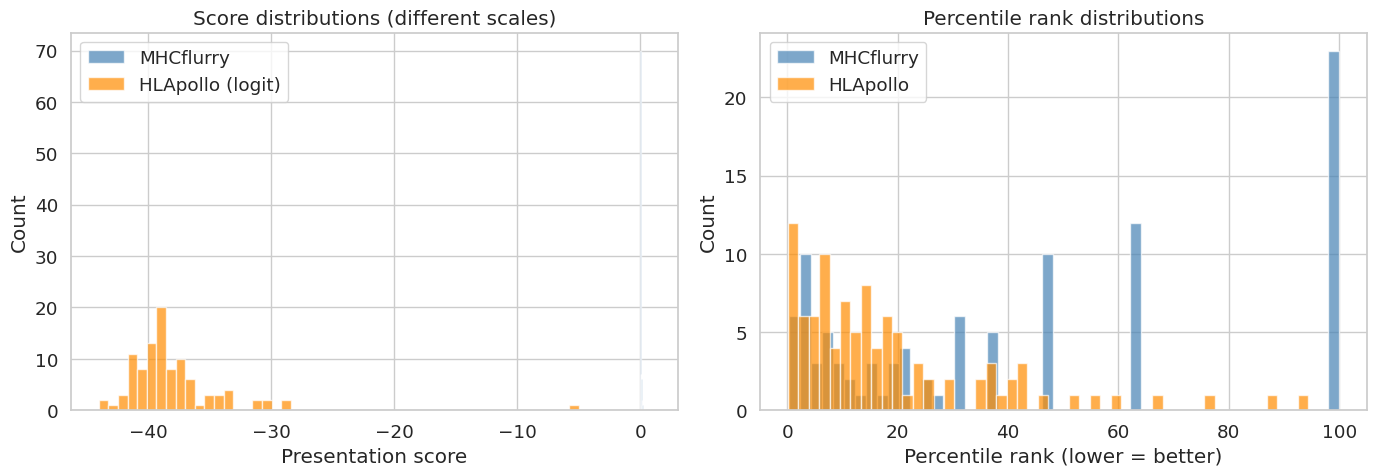

In [10]:
if ap_df is not None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Scores (different scales — MHCflurry is 0-1, HLApollo is a logit)
    axes[0].hist(combined["mf_presentation_score"], bins=50, alpha=0.7, label="MHCflurry", color="steelblue")
    axes[0].hist(combined["ap_score"], bins=50, alpha=0.7, label="HLApollo (logit)", color="darkorange")
    axes[0].set_xlabel("Presentation score")
    axes[0].set_ylabel("Count")
    axes[0].set_title("Score distributions (different scales)")
    axes[0].legend()

    # Percentile ranks (comparable across predictors)
    axes[1].hist(combined["mf_percentile"], bins=50, alpha=0.7, label="MHCflurry", color="steelblue")
    axes[1].hist(combined["ap_percentile"], bins=50, alpha=0.7, label="HLApollo", color="darkorange")
    axes[1].set_xlabel("Percentile rank (lower = better)")
    axes[1].set_ylabel("Count")
    axes[1].set_title("Percentile rank distributions")
    axes[1].legend()

    plt.tight_layout()
    plt.show()
else:
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.hist(mf_df["mf_presentation_score"], bins=50, color="steelblue", alpha=0.8)
    ax.set_xlabel("MHCflurry presentation score")
    ax.set_ylabel("Count")
    ax.set_title("MHCflurry score distribution (HCC1395)")
    plt.show()

## 3. Rank correlation

Spearman rank correlation (percentile): ρ = 0.406, p = 2.79e-05


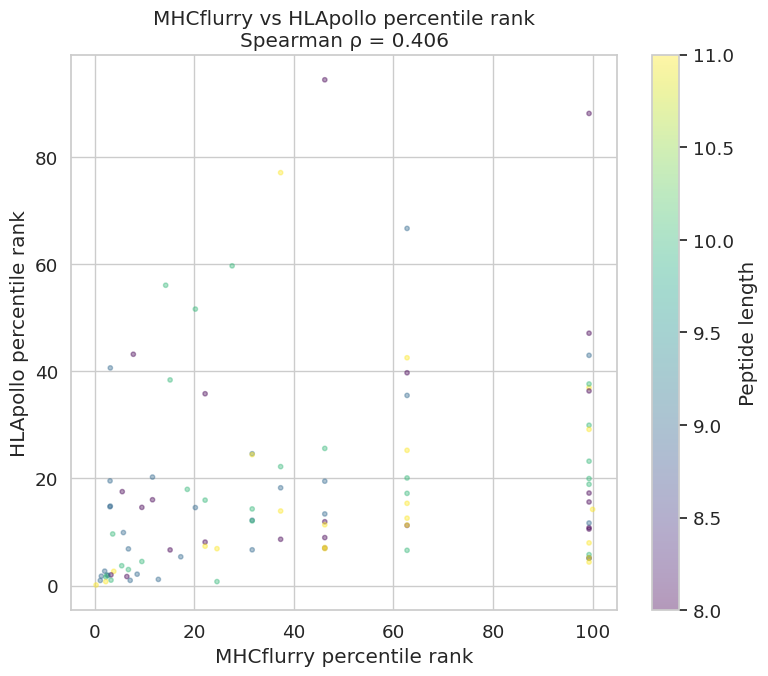

In [11]:
if ap_df is not None:
    rho, pval = stats.spearmanr(combined["mf_percentile"], combined["ap_percentile"])
    print(f"Spearman rank correlation (percentile): ρ = {rho:.3f}, p = {pval:.2e}")

    fig, ax = plt.subplots(figsize=(8, 7))
    sc = ax.scatter(
        combined["mf_percentile"],
        combined["ap_percentile"],
        c=combined["peptide_length"],
        cmap="viridis",
        alpha=0.4,
        s=10,
    )
    plt.colorbar(sc, ax=ax, label="Peptide length")
    ax.set_xlabel("MHCflurry percentile rank")
    ax.set_ylabel("HLApollo percentile rank")
    ax.set_title(f"MHCflurry vs HLApollo percentile rank\nSpearman ρ = {rho:.3f}")
    plt.tight_layout()
    plt.show()
else:
    print("HLApollo predictions not available; skipping rank correlation.")

## 4. Top candidate concordance

In [12]:
if ap_df is not None:
    thresholds = [20, 50, 100]
    print(f"{'Threshold':>12} | {'MHCflurry':>10} | {'HLApollo':>10} | {'Overlap':>8} | {'Jaccard':>8}")
    print("-" * 60)

    for k in thresholds:
        mf_top = set(combined.nsmallest(k, "mf_percentile")["peptide"])
        ap_top = set(combined.nsmallest(k, "ap_percentile")["peptide"])
        overlap = mf_top & ap_top
        union = mf_top | ap_top
        jaccard = len(overlap) / len(union) if union else 0.0
        print(f"Top {k:>8} | {len(mf_top):>10} | {len(ap_top):>10} | {len(overlap):>8} | {jaccard:>8.3f}")

    # Peptides in MHCflurry top 20 but not HLApollo top 20
    mf_top20 = combined.nsmallest(20, "mf_percentile").set_index("peptide")
    ap_top20 = combined.nsmallest(20, "ap_percentile").set_index("peptide")
    mf_only = mf_top20[~mf_top20.index.isin(ap_top20.index)]
    ap_only = ap_top20[~ap_top20.index.isin(mf_top20.index)]

    print(f"\nIn MHCflurry top 20 but not HLApollo top 20 ({len(mf_only)} peptides):")
    display(mf_only[["gene", "mutation_str", "mf_percentile", "ap_percentile"]].reset_index())

    print(f"\nIn HLApollo top 20 but not MHCflurry top 20 ({len(ap_only)} peptides):")
    display(ap_only[["gene", "mutation_str", "mf_percentile", "ap_percentile"]].reset_index())
else:
    print("HLApollo predictions not available; showing MHCflurry top 20:")
    display(mf_df.nsmallest(20, "mf_percentile")[["peptide", "gene", "mutation_str", "mf_percentile"]])

   Threshold |  MHCflurry |   HLApollo |  Overlap |  Jaccard
------------------------------------------------------------
Top       20 |         20 |         20 |       13 |    0.481
Top       50 |         50 |         50 |       30 |    0.429
Top      100 |        100 |        100 |      100 |    1.000

In MHCflurry top 20 but not HLApollo top 20 (7 peptides):


,peptide,gene,mutation_str,mf_percentile,ap_percentile
0,VTPMGWGCL,SRARP,SRARP_p.Gly100Trp,3.082636,14.705603
1,TPMGWGCLA,SRARP,SRARP_p.Gly100Trp,3.106549,19.539026
2,AMYFLLASL,OR4F16,OR4F16_p.Pro58Ala,3.158859,40.619759
3,TQGVHPRRW,PRAMEF15,PRAMEF15_p.Arg96His,3.158859,14.834526
4,ALLTQGVHPR,PRAMEF15,PRAMEF15_p.Arg96His,3.639185,9.634933
5,TQGVHPRR,PRAMEF15,PRAMEF15_p.Arg96His,5.554946,17.534781
6,LLTQGVHPR,PRAMEF15,PRAMEF15_p.Arg96His,5.788071,9.898602



In HLApollo top 20 but not MHCflurry top 20 (7 peptides):


,peptide,gene,mutation_str,mf_percentile,ap_percentile
0,DALLTQGVHP,PRAMEF15,PRAMEF15_p.Arg96His,24.579239,0.744614
1,HLHSAMYFL,OR4F16,OR4F16_p.Pro58Ala,7.147065,0.976763
2,LHSAMYFLL,OR4F16,OR4F16_p.Pro58Ala,12.805462,1.160491
3,LTQGVHPRR,PRAMEF15,PRAMEF15_p.Arg96His,8.545326,2.130815
4,VTTDPHLHSA,OR4F16,OR4F16_p.Pro58Ala,6.792609,2.993969
5,LDALLTQGVHP,PRAMEF15,PRAMEF15_p.Arg96His,99.286603,4.395621
6,DPHLHSAMYF,OR4F16,OR4F16_p.Pro58Ala,9.494239,4.498961


## 5. Allele-specific comparison

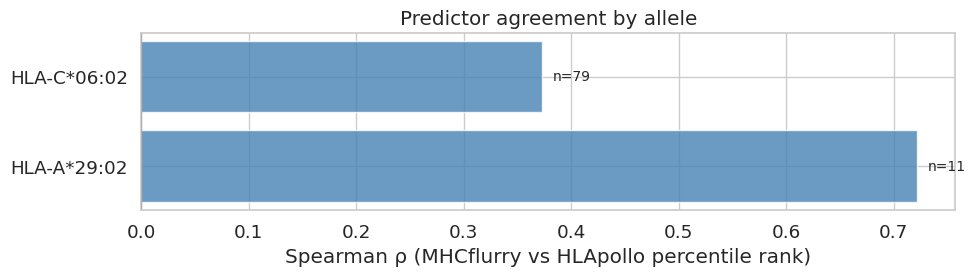

In [13]:
if ap_df is not None:
    allele_corr = []
    for allele in combined["mf_best_allele"].unique():
        subset = combined[combined["mf_best_allele"] == allele]
        if len(subset) < 10:
            continue
        rho, _ = stats.spearmanr(subset["mf_percentile"], subset["ap_percentile"])
        allele_corr.append({"allele": allele, "n": len(subset), "spearman_rho": rho})

    if allele_corr:
        corr_df = pd.DataFrame(allele_corr).sort_values("spearman_rho", ascending=False)

        fig, ax = plt.subplots(figsize=(10, max(3, len(corr_df) * 0.6)))
        bars = ax.barh(corr_df["allele"], corr_df["spearman_rho"], color="steelblue", alpha=0.8)
        ax.set_xlabel("Spearman ρ (MHCflurry vs HLApollo percentile rank)")
        ax.set_title("Predictor agreement by allele")
        ax.axvline(0, color="black", linewidth=0.8)
        for bar, row in zip(bars, corr_df.itertuples()):
            ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
                    f"n={row.n}", va="center", fontsize=10)
        plt.tight_layout()
        plt.show()
    else:
        print("No allele has ≥10 peptides for correlation.")
else:
    print("Allele-specific comparison requires HLApollo predictions.")

## 6. Expression-stratified comparison

Expression data available for 349 genes
Peptides with expression data: 100/100


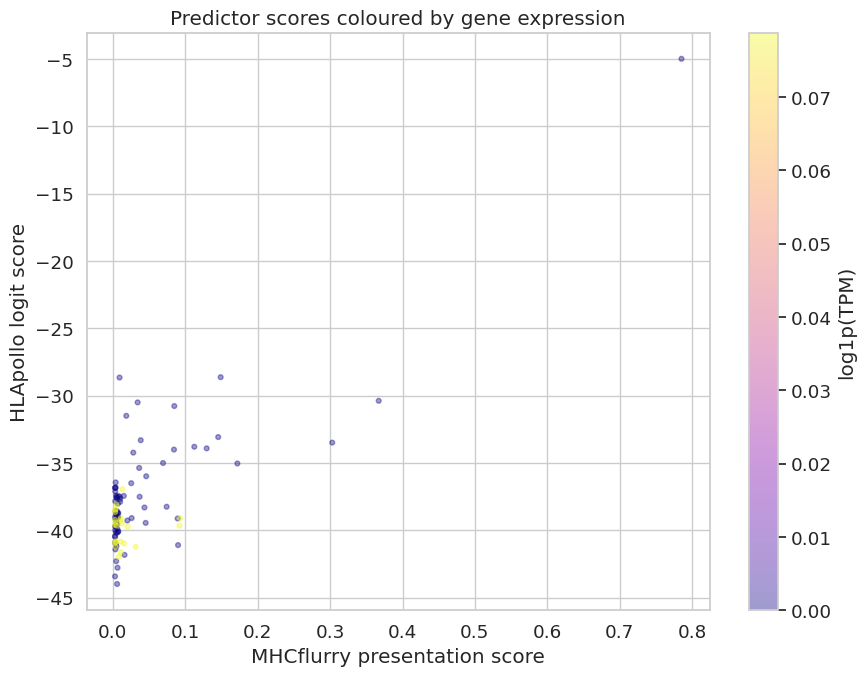

In [14]:
# Pull expression from variant annotations (gene → TPM)
expr_map = {v.gene: v.expression for v in variants if v.expression is not None}
print(f"Expression data available for {len(expr_map)} genes")

mf_df["expression"] = mf_df["gene"].map(expr_map)

if ap_df is not None:
    combined["expression"] = combined["gene"].map(expr_map)
    expressed = combined.dropna(subset=["expression"])
    print(f"Peptides with expression data: {len(expressed)}/{len(combined)}")

    fig, ax = plt.subplots(figsize=(9, 7))
    sc = ax.scatter(
        expressed["mf_presentation_score"],
        expressed["ap_score"],
        c=np.log1p(expressed["expression"]),
        cmap="plasma",
        alpha=0.4,
        s=12,
    )
    plt.colorbar(sc, ax=ax, label="log1p(TPM)")
    ax.set_xlabel("MHCflurry presentation score")
    ax.set_ylabel("HLApollo logit score")
    ax.set_title("Predictor scores coloured by gene expression")
    plt.tight_layout()
    plt.show()
else:
    expressed = mf_df.dropna(subset=["expression"])
    print(f"Peptides with expression data: {len(expressed)}/{len(mf_df)}")
    fig, ax = plt.subplots(figsize=(9, 6))
    ax.scatter(
        np.log1p(expressed["expression"]),
        expressed["mf_presentation_score"],
        alpha=0.4,
        s=12,
        color="steelblue",
    )
    ax.set_xlabel("log1p(TPM)")
    ax.set_ylabel("MHCflurry presentation score")
    ax.set_title("MHCflurry score vs gene expression")
    plt.tight_layout()
    plt.show()

## 7. Case studies: largest disagreements

In [15]:
if ap_df is not None:
    combined["rank_diff"] = abs(combined["mf_percentile"] - combined["ap_percentile"])
    cols = ["peptide", "gene", "mutation_str", "mf_best_allele", "ap_best_allele",
            "mf_presentation_score", "mf_percentile", "ap_score", "ap_percentile", "rank_diff"]
    top_disagreements = combined.nlargest(5, "rank_diff")[cols]

    print("Top 5 peptides where MHCflurry and HLApollo disagree most:")
    display(top_disagreements)
else:
    print("Case studies require HLApollo predictions.")
    print("\nTop 5 MHCflurry candidates:")
    display(mf_df.nsmallest(5, "mf_percentile")[["peptide", "gene", "mutation_str", "mf_best_allele", "mf_percentile"]])

Top 5 peptides where MHCflurry and HLApollo disagree most:


,peptide,gene,mutation_str,mf_best_allele,ap_best_allele,mf_presentation_score,mf_percentile,ap_score,ap_percentile,rank_diff
66,LDALLTQGVHP,PRAMEF15,PRAMEF15_p.Arg96His,HLA-C*06:02,HLA-C*06:02,0.003972,99.286603,-36.448588,4.395621,94.890983
53,VHPRRWKLQ,PRAMEF15,PRAMEF15_p.Arg96His,HLA-C*06:02,HLA-C*06:02,0.003810,99.286603,-36.821384,5.098829,94.187774
45,HPRRWKLQ,PRAMEF15,PRAMEF15_p.Arg96His,HLA-B*82:02,HLA-C*06:02,0.003249,99.286603,-36.853914,5.167222,94.119381
72,QGVHPRRWKLQ,PRAMEF15,PRAMEF15_p.Arg96His,HLA-C*06:02,HLA-C*06:02,0.003224,99.286603,-36.859833,5.179125,94.107478
62,GVHPRRWKLQ,PRAMEF15,PRAMEF15_p.Arg96His,HLA-C*06:02,HLA-C*06:02,0.003347,99.286603,-37.122749,5.779593,93.507010


## 8. ESM-2 features (if available)

In [16]:
try:
    import esm  # noqa: F401
    import h5py  # noqa: F401
    ESM_AVAILABLE = True
except ImportError:
    ESM_AVAILABLE = False

if ESM_AVAILABLE:
    from neoantigen_pipeline.prediction.esm_embeddings import ESMEmbeddingCache

    cache = ESMEmbeddingCache(cache_path="../results/esm_cache.h5")
    print("ESM-2 available. Computing structural scores for top candidates...")

    rank_col = "ap_percentile" if ap_df is not None else "mf_percentile"
    top_peptides = set(combined.nsmallest(50, rank_col)["peptide"])
    top_candidates = [c for c in all_candidates if c.peptide_sequence in top_peptides]

    esm_scores = []
    for c in top_candidates[:20]:  # limit to 20 for speed
        seq = proteome.get_sequence(c.transcript_id)
        if seq:
            features = cache.extract_peptide_features(
                c.transcript_id, seq,
                start=c.aa_pos - 1,
                end=c.aa_pos - 1 + c.peptide_length,
            )
            esm_scores.append({
                "peptide": c.peptide_sequence,
                "gene": c.gene,
                "esm_magnitude": float(np.linalg.norm(features)),
            })

    esm_df = pd.DataFrame(esm_scores)
    display(esm_df)
else:
    print("ESM-2 not installed. Install with: pip install 'neoantigen-pipeline[esm]'")

ESM-2 not installed. Install with: pip install 'neoantigen-pipeline[esm]'
